**Trainer Notebook**

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset
df =pd.read_csv('https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/prepreprocessing/pre_data.csv')
df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,NaN,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [ ]:
df.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,NaN,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes


In [ ]:
df.tail()

,Country,Age,Salary,Purchased
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes
10,Germany,50.0,83000.0,No
11,Spain,50.0,1500000.0,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    11 non-null     object 
 1   Age        11 non-null     float64
 2   Salary     11 non-null     float64
 3   Purchased  12 non-null     object 
dtypes: float64(2), object(2)
memory usage: 516.0+ bytes


In [ ]:
df.describe(include='all')

,Country,Age,Salary,Purchased
count,9,9.000000,9.000000e+00,9
unique,3,NaN,NaN,2
top,France,NaN,NaN,No
freq,4,NaN,NaN,5
mean,NaN,42.111111,2.278889e+05,NaN
std,NaN,8.268078,4.771898e+05,NaN
min,NaN,27.000000,4.800000e+04,NaN
25%,NaN,37.000000,6.100000e+04,NaN
50%,NaN,44.000000,7.200000e+04,NaN
75%,NaN,50.000000,8.300000e+04,NaN


Preprocessing

In [ ]:
#Step 1 CHeck Missing Values
df.isnull().sum()

,0
Country,1
Age,1
Salary,1
Purchased,0


In [ ]:
df.isna().sum()

,0
Country,1
Age,1
Salary,1
Purchased,0


In [ ]:
df2 = df.copy()

In [ ]:
#Dropping
df.dropna(inplace=True)
df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
3,Spain,38.0,61000.0,No
5,France,35.0,58000.0,Yes
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes
10,Germany,50.0,83000.0,No
11,Spain,50.0,1500000.0,No


In [ ]:
#Imputation df2 using fillna
df2['Age'] = df2['Age'].fillna(df2['Age'].mean())
df2['Salary'] = df2['Salary'].fillna(df2['Salary'].mean())
df2['Country'] = df2['Country'].fillna(df2['Country'].mode()[0])
df2

,Country,Age,Salary,Purchased
0,France,44.000000,7.200000e+04,No
1,Spain,27.000000,4.800000e+04,Yes
2,France,30.000000,5.400000e+04,No
3,Spain,38.000000,6.100000e+04,No
4,Germany,40.000000,1.960909e+05,Yes
5,France,35.000000,5.800000e+04,Yes
6,Spain,40.818182,5.200000e+04,No
7,France,48.000000,7.900000e+04,Yes
8,Germany,50.000000,8.300000e+04,No
9,France,37.000000,6.700000e+04,Yes


In [ ]:
#Check duplicates
df2.duplicated().sum()

np.int64(1)

In [ ]:
#Remove Duplicates
df2.drop_duplicates(inplace=True)
df2

,Country,Age,Salary,Purchased
0,France,44.000000,7.200000e+04,No
1,Spain,27.000000,4.800000e+04,Yes
2,France,30.000000,5.400000e+04,No
3,Spain,38.000000,6.100000e+04,No
4,Germany,40.000000,1.960909e+05,Yes
5,France,35.000000,5.800000e+04,Yes
6,Spain,40.818182,5.200000e+04,No
7,France,48.000000,7.900000e+04,Yes
8,Germany,50.000000,8.300000e+04,No
9,France,37.000000,6.700000e+04,Yes


<Axes: ylabel='Age'>

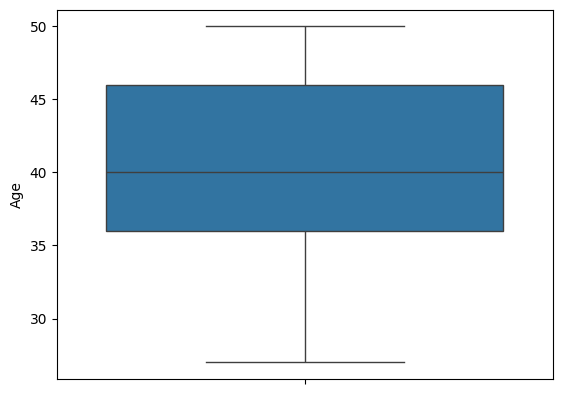

In [ ]:
#Check outliers - Boxplot
#Age
sns.boxplot(df2['Age'])

<Axes: ylabel='Salary'>

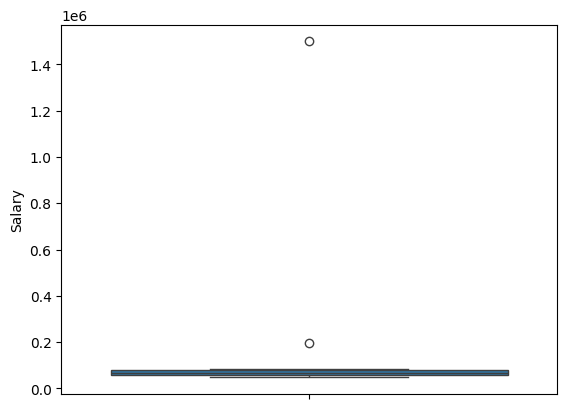

In [ ]:
#Age has no Outliers
#Check Salary
sns.boxplot(df2['Salary'])

In [ ]:
# Identify the quartiles
q1, q3 = np.percentile(df2['Salary'], [25, 75])
# Calculate the interquartile range
iqr = q3 - q1
# Calculate the lower and upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
print(lower_bound, upper_bound)
# Drop the outliers
df2 = df2[(df2['Salary'] >= lower_bound)  & (df2['Salary'] <= upper_bound)]
df2

18500.0 118500.0


,Country,Age,Salary,Purchased
0,France,44.000000,72000.0,No
1,Spain,27.000000,48000.0,Yes
2,France,30.000000,54000.0,No
3,Spain,38.000000,61000.0,No
5,France,35.000000,58000.0,Yes
6,Spain,40.818182,52000.0,No
7,France,48.000000,79000.0,Yes
8,Germany,50.000000,83000.0,No
9,France,37.000000,67000.0,Yes


In [ ]:
df2['Country'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [ ]:
df2['Purchased'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df2['Country'] = le.fit_transform(df2['Country'])
print(le.classes_)
df2['Purchased'] = le.fit_transform(df2['Purchased'])
print(le.classes_)
df2


['France' 'Germany' 'Spain']
['No' 'Yes']


/tmp/ipykernel_4196/2951526143.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Country'] = le.fit_transform(df2['Country'])
/tmp/ipykernel_4196/2951526143.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Purchased'] = le.fit_transform(df2['Purchased'])


,Country,Age,Salary,Purchased
0,0,44.000000,72000.0,0
1,2,27.000000,48000.0,1
2,0,30.000000,54000.0,0
3,2,38.000000,61000.0,0
5,0,35.000000,58000.0,1
6,2,40.818182,52000.0,0
7,0,48.000000,79000.0,1
8,1,50.000000,83000.0,0
9,0,37.000000,67000.0,1


In [ ]:
#Feature Scaling
df3 = df2.copy()

In [ ]:
#Feature Scaling - MinMax
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df3[['Age','Salary']] = scaler.fit_transform(df3[['Age','Salary']])
df3

,Country,Age,Salary,Purchased
0,0,0.739130,0.685714,0
1,2,0.000000,0.000000,1
2,0,0.130435,0.171429,0
3,2,0.478261,0.371429,0
5,0,0.347826,0.285714,1
6,2,0.600791,0.114286,0
7,0,0.913043,0.885714,1
8,1,1.000000,1.000000,0
9,0,0.434783,0.542857,1


In [ ]:
#Standard Scaling
from sklearn.preprocessing import StandardScaler
ssc = StandardScaler()
df2[['Age','Salary']] = ssc.fit_transform(df2[['Age','Salary']])
df2

/tmp/ipykernel_4196/703557812.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['Age','Salary']] = ssc.fit_transform(df2[['Age','Salary']])


,Country,Age,Salary,Purchased
0,0,0.705468,0.711013,0
1,2,-1.631743,-1.364376,1
2,0,-1.219294,-0.845529,0
3,2,-0.119430,-0.240207,0
5,0,-0.531879,-0.499631,1
6,2,0.268022,-1.018478,0
7,0,1.255401,1.316334,1
8,1,1.530367,1.662233,0
9,0,-0.256913,0.278640,1
